In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuração
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving archive (3) (2).zip to archive (3) (2).zip
User uploaded file "archive (3) (2).zip" with length 8963711 bytes


In [ ]:
import zipfile

# Assuming the zip file is in /content/ and named 'archive (3) (2).zip'
zip_file_path = '/content/archive (3) (2).zip'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Now read the parquet file, assuming it's directly in the unzipped directory
df = pd.read_parquet('/content/documentation.parquet')

df.head()

,id,repo_full_name,file_name,content,file_size,readme_quality_score,collected_at
0,2454,0xN1nja/homepagectl,README.md,# homepagectl\n\nTired of manually writing homepage configs every time you spin up a new container? `homepagectl` fixes that.\n\nQueries your Dock...,2041,42,2026-06-27 19:14:23.602441
1,2455,0xN1nja/homepagectl,go.mod,module github.com/0xN1nja/homepagectl\n\ngo 1.25.0\n\nrequire (\n\tgithub.com/BurntSushi/toml v1.6.0\n\tgithub.com/spf13/cobra v1.10.2\n)\n\nrequi...,242,0,2026-06-27 19:14:43.368223
2,2158,0xNyk/council-of-high-intelligence,CHANGELOG.md,# Changelog\n\nAll notable changes to this project will be documented in this file.\nFormat follows [Keep a Changelog](https://keepachangelog.com/...,5454,0,2026-06-27 18:22:28.437941
3,2157,0xNyk/council-of-high-intelligence,CONTRIBUTING.md,# Contributing\n\nThanks for contributing to Council of High Intelligence.\n\n## Development flow\n\n1. Sync main:\n - `git checkout main`\n -...,941,0,2026-06-27 18:22:26.587716
4,2156,0xNyk/council-of-high-intelligence,LICENSE,"MIT License\n\nCopyright (c) 2026 nyk\n\nPermission is hereby granted, free of charge, to any person obtaining a copy\nof this software and associ...",1060,0,2026-06-27 18:22:24.846284


In [ ]:
df.describe(include="all")

,id,repo_full_name,file_name,content,file_size,readme_quality_score,collected_at
count,2900.000000,2900,2900,2900,2.900000e+03,2900.000000,2900
unique,NaN,986,14,2739,NaN,NaN,2900
top,NaN,bmad-code-org/BMAD-METHOD,README.md,"Apache License\n Version 2.0, January 2004\n http://www.apache.o...",NaN,NaN,2026-06-27 18:27:19.967175
freq,NaN,11,944,29,NaN,NaN,1
mean,1450.500000,NaN,NaN,NaN,1.186009e+04,19.573448,NaN
std,837.302215,NaN,NaN,NaN,3.968231e+04,30.846577,NaN
min,1.000000,NaN,NaN,NaN,1.000000e+00,0.000000,NaN
25%,725.750000,NaN,NaN,NaN,1.084000e+03,0.000000,NaN
50%,1450.500000,NaN,NaN,NaN,3.368500e+03,0.000000,NaN
75%,2175.250000,NaN,NaN,NaN,1.006425e+04,44.000000,NaN


In [ ]:
df.columns

Index(['id', 'repo_full_name', 'file_name', 'content', 'file_size',
       'readme_quality_score', 'collected_at'],
      dtype='object')

In [ ]:
print(f"Número de documentos: {len(df)}")

Número de documentos: 2900


In [ ]:
df.isnull().sum()

,0
id,0
repo_full_name,0
file_name,0
content,0
file_size,0
readme_quality_score,0
collected_at,0


In [ ]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [ ]:
print(df.loc[0, "content"])

# homepagectl

Tired of manually writing homepage configs every time you spin up a new container? `homepagectl` fixes that.

Queries your Docker socket, matches containers against homepage known services, auto-detects ports, and writes `services.yaml`, `settings.yaml`, and `.env` — no manual YAML editing required.

## Installation

```bash
git clone https://github.com/0xN1nja/homepagectl.git
cd homepagectl
make build
sudo mv homepagectl /usr/local/bin/
```

## Usage

```bash
homepagectl init | tee <path-to-homepage-config>/homepagectl.toml
homepagectl list
homepagectl generate --output <path-to-homepage-config>
homepagectl generate --output <path-to-homepage-config> --dry-run
```

| Command     | Description                                       |
| ----------- | ------------------------------------------------- |
| `init`      | Generate a `homepagectl.toml` config file         |
| `list`      | Preview detected containers, widgets and groups   |
| `generate`  | Write `services.yaml`,

In [ ]:
df["num_caracteres"] = df["content"].str.len()

In [ ]:
df["num_caracteres"].describe()

,num_caracteres
count,2.900000e+03
mean,1.186009e+04
std,3.968231e+04
min,1.000000e+00
25%,1.084000e+03
50%,3.368500e+03
75%,1.006425e+04
max,1.013607e+06


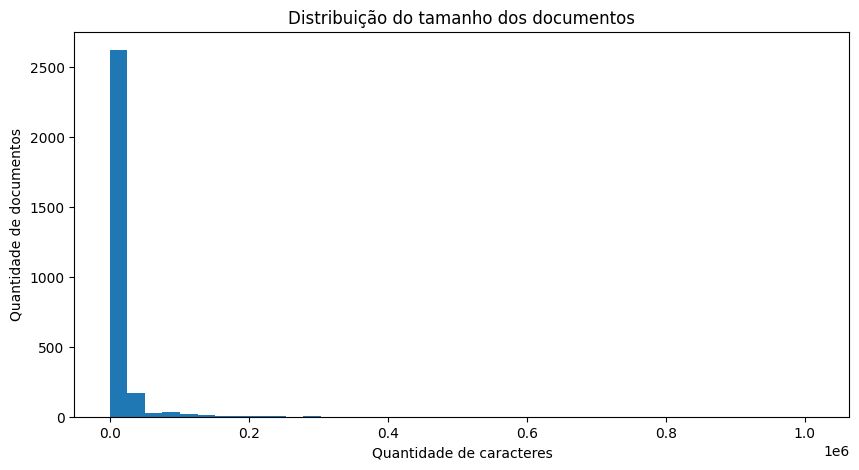

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df["num_caracteres"], bins=40)

plt.title("Distribuição do tamanho dos documentos")

plt.xlabel("Quantidade de caracteres")

plt.ylabel("Quantidade de documentos")

plt.show()

In [ ]:
df["file_name"].value_counts().head(20)

,count
file_name,
README.md,944
LICENSE,646
CONTRIBUTING.md,262
package.json,213
CHANGELOG.md,197
CODE_OF_CONDUCT.md,130
SECURITY.md,122
pyproject.toml,72
Gemfile,70


In [ ]:
df["repo_full_name"].value_counts().head(20)

,count
repo_full_name,
bmad-code-org/BMAD-METHOD,11
vinta/awesome-python,10
openclaw/openclaw,10
gradio-app/gradio,9
TanStack/query,8
Hmbown/CodeWhale,8
jazzband/django-silk,8
jestjs/jest,7
mediacms-io/mediacms,7


In [ ]:
df["readme_quality_score"].describe()

,readme_quality_score
count,2900.000000
mean,19.573448
std,30.846577
min,0.000000
25%,0.000000
50%,0.000000
75%,44.000000
max,95.000000


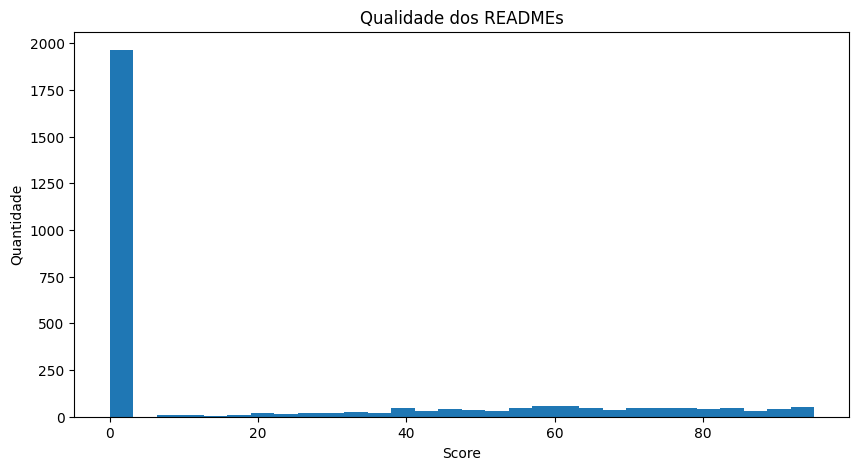

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df["readme_quality_score"], bins=30)

plt.title("Qualidade dos READMEs")

plt.xlabel("Score")

plt.ylabel("Quantidade")

plt.show()

In [ ]:
maior = df["num_caracteres"].idxmax()

df.loc[maior]

,779
id,2188
repo_full_name,asklokesh/loki-mode
file_name,CHANGELOG.md
content,# Changelog\n\nAll notable changes to Loki Mode will be documented in this file.\n\nThe format is based on [Keep a Changelog](https://keepachangel...
file_size,1013607
readme_quality_score,0
collected_at,2026-06-27 18:28:24.699337
num_caracteres,1013607


In [ ]:
menor = df["num_caracteres"].idxmin()

df.loc[menor]

,1716
id,2369
repo_full_name,kprprivate/EAC-CR3-BYPASS
file_name,README.md
content,\n
file_size,1
readme_quality_score,0
collected_at,2026-06-27 18:58:59.660419
num_caracteres,1


In [ ]:
df.to_csv("documentation_limpo.csv", index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    2900 non-null   int32 
 1   repo_full_name        2900 non-null   object
 2   file_name             2900 non-null   object
 3   content               2900 non-null   object
 4   file_size             2900 non-null   int32 
 5   readme_quality_score  2900 non-null   int32 
 6   collected_at          2900 non-null   object
 7   num_caracteres        2900 non-null   int64 
dtypes: int32(3), int64(1), object(4)
memory usage: 147.4+ KB


In [ ]:
df.describe(include="all")

,id,repo_full_name,file_name,content,file_size,readme_quality_score,collected_at,num_caracteres
count,2900.000000,2900,2900,2900,2.900000e+03,2900.000000,2900,2.900000e+03
unique,NaN,986,14,2739,NaN,NaN,2900,NaN
top,NaN,bmad-code-org/BMAD-METHOD,README.md,"Apache License\n Version 2.0, January 2004\n http://www.apache.o...",NaN,NaN,2026-06-27 18:27:19.967175,NaN
freq,NaN,11,944,29,NaN,NaN,1,NaN
mean,1450.500000,NaN,NaN,NaN,1.186009e+04,19.573448,NaN,1.186009e+04
std,837.302215,NaN,NaN,NaN,3.968231e+04,30.846577,NaN,3.968231e+04
min,1.000000,NaN,NaN,NaN,1.000000e+00,0.000000,NaN,1.000000e+00
25%,725.750000,NaN,NaN,NaN,1.084000e+03,0.000000,NaN,1.084000e+03
50%,1450.500000,NaN,NaN,NaN,3.368500e+03,0.000000,NaN,3.368500e+03
75%,2175.250000,NaN,NaN,NaN,1.006425e+04,44.000000,NaN,1.006425e+04


In [ ]:
df["file_name"].value_counts().head(20)

,count
file_name,
README.md,944
LICENSE,646
CONTRIBUTING.md,262
package.json,213
CHANGELOG.md,197
CODE_OF_CONDUCT.md,130
SECURITY.md,122
pyproject.toml,72
Gemfile,70


In [ ]:
df["repo_full_name"].value_counts().head(20)

,count
repo_full_name,
bmad-code-org/BMAD-METHOD,11
vinta/awesome-python,10
openclaw/openclaw,10
gradio-app/gradio,9
TanStack/query,8
Hmbown/CodeWhale,8
jazzband/django-silk,8
jestjs/jest,7
mediacms-io/mediacms,7


In [ ]:
df["content"].duplicated().sum()

np.int64(161)

In [ ]:
(df["num_caracteres"] < 100).sum()

np.int64(67)

In [ ]:
(df["num_caracteres"] < 200).sum()

np.int64(135)

In [ ]:
df["num_caracteres"].describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99])

,num_caracteres
count,2.900000e+03
mean,1.186009e+04
std,3.968231e+04
min,1.000000e+00
25%,1.084000e+03
50%,3.368500e+03
75%,1.006425e+04
90%,2.356050e+04
95%,3.621600e+04
99%,1.484334e+05


In [ ]:
# Salvar a base utilizada na EDA
df.to_parquet("/content/documentation_eda.parquet", index=False)

print("Base da EDA salva com sucesso!")

Base da EDA salva com sucesso!


In [ ]:
df.to_csv("/content/documentation_eda.csv", index=False)

In [ ]:
from google.colab import files

files.download("/content/documentation_eda.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!find /content/drive/MyDrive -name "01_EDA.ipynb"

/content/drive/MyDrive/Hackathon_ONE/01_EDA.ipynb


In [5]:
!pwd

/content


In [7]:
!ls

drive  sample_data


In [8]:
!git clone https://github.com/No-Country-simulation/S1-BR-G9-TEAM07-TechMind.git

Cloning into 'S1-BR-G9-TEAM07-TechMind'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 96 (delta 14), reused 78 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 74.39 KiB | 4.65 MiB/s, done.
Resolving deltas: 100% (14/14), done.
